<a href="https://colab.research.google.com/github/ScarrryMary/IT_MIPT_group25-26/blob/main/2_semester/Seminar2_4_25_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

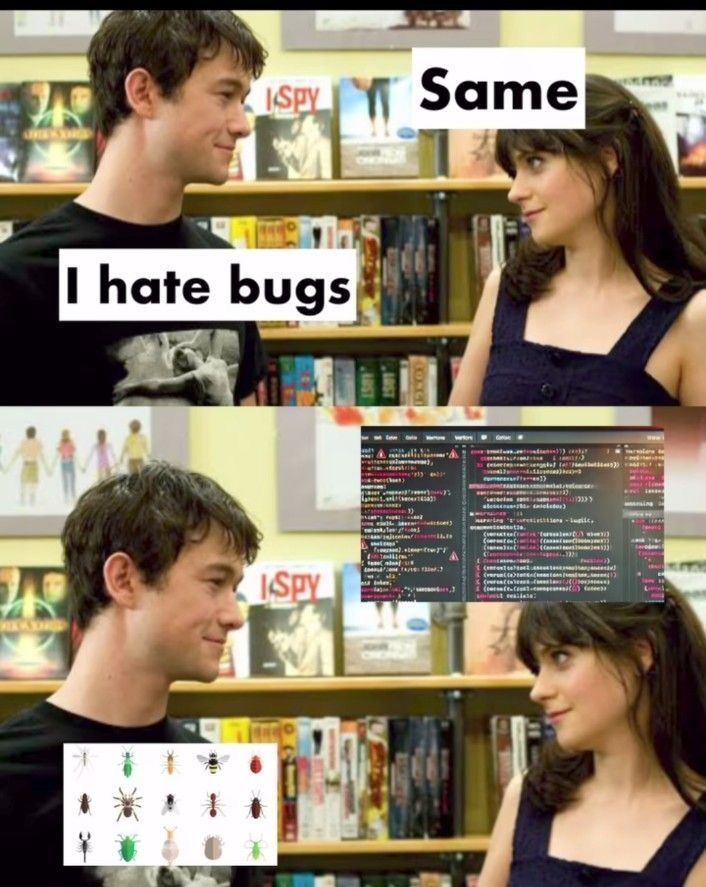

# Алгоритм Борувки

Переформулируем лемму о безопасном ребре в частном случае:

**Лемма.** Для любой вершины минимальное инцидентное ей реборо является безопасным.

**Доказательство.** Пусть есть минимальный остов, в котором для какой-то вершины $v$ нет её минимального инцидентного ребра. Тогда, если добавить это ребро, образуется цикл, из которого можно удалить другое ребро, тоже инцидентное $v$, но имеющее не меньший вес.

Алгоритм Борувки опирается на этот факт и заключается в следующем:

1. Для каждой вершины найдем минимальное инцидентное ей ребро.
2. Добавим все такие рёбра в остов (это безопасно — см. лемму) и сожмем получившиеся компоненты, то есть объединим списки смежности вершин, которые эти рёбра соединяют.
3. Повторяем шаги 1-2, пока в графе не останется только одна вершина-компонента.

Алгоритм может работать неправильно, если в графе есть ребра, равные по весу. Пример: «треугольник» с одинаковыми весами рёбер. Избежать такую ситуацию можно, введя какой-то дополнительный порядок на рёбрах — например, сравнивая пары из веса и номера ребра.

Заметим, что на каждой итерации каждая оставшаяся вершина будет задействована в «мердже». Это значит, что количество вершин-компонент уменьшится хотя бы вдвое, а значит всего итераций будет не более $O(logn)$.

На каждой итерации мы просматриваем почти все рёбра, так что итоговое время работы составит $O(mlogn)$.

In [3]:
def boruvka(graph, n):
    """
    Алгоритм Борувки для MST
    graph: [[(v,w)], ...]
    """
    parent = list(range(n))
    print(parent)

    def find(x):
        if parent[x] != x:
            print(f'X: {x}, parent: {parent[x]}')
            parent[x] = find(parent[x])
        return parent[x]

    mst_weight = 0
    edges_used = []

    while True:
        # 1. Параллельно: min ребро для КАЖДОЙ компоненты
        min_edges = {}  # {(comp1,comp2): (w,u,v)}

        for u in range(n):
            for v, w in graph[u]:
                if u < v:  # избегаем дублей
                    pu, pv = find(u), find(v)
                    if pu != pv:
                        key = (min(pu,pv), max(pu,pv))
                        if key not in min_edges or w < min_edges[key][0]:
                            min_edges[key] = (w, u, v)

        # 2. Добавляем найденные рёбра
        added = 0
        for (w, u, v) in min_edges.values():
            pu, pv = find(u), find(v)
            if pu != pv:
                parent[pu] = pv
                mst_weight += w
                edges_used.append((u, v, w))
                added += 1

        print(f"Итерация: +{added} рёбер, вес={mst_weight}")
        if added == 0:  # 1 компонента
            break

    return mst_weight, edges_used

graph = [
    [(1,2), (3,1)],    # 0
    [(0,2), (2,1)],    # 1
    [(1,1), (3,2)],    # 2
    [(0,1), (2,2), (7,5)], # 3
    [(5,3)],           # 4
    [(4,3), (6,1)],    # 5
    [(5,1)],           # 6
    [(3,5)]            # 7
]

weight, edges = boruvka(graph, 8)
print(f"\nMST вес: {weight}")
print("Рёбра:", edges)


[0, 1, 2, 3, 4, 5, 6, 7]
X: 0, parent: 1
X: 1, parent: 3
X: 3, parent: 2
X: 3, parent: 2
Итерация: +6 рёбер, вес=13
X: 0, parent: 1
X: 1, parent: 3
X: 3, parent: 2
X: 2, parent: 7
X: 1, parent: 7
X: 0, parent: 7
X: 3, parent: 7
X: 1, parent: 7
X: 2, parent: 7
X: 2, parent: 7
X: 3, parent: 7
X: 3, parent: 7
X: 4, parent: 5
X: 5, parent: 6
X: 5, parent: 6
X: 5, parent: 6
Итерация: +0 рёбер, вес=13

MST вес: 13
Рёбра: [(0, 1, 2), (0, 3, 1), (1, 2, 1), (3, 7, 5), (4, 5, 3), (5, 6, 1)]


# Паросочетания
Задача. Пусть есть $n$ мальчиков и $m$ девочек. Про каждого мальчика и про каждую девочку известно, с кем они не против танцевать. Нужно составить как можно больше пар, в которых партнёры хотят танцевать друг с другом.

Формализуем эту задачу, представив мальчиков и девочек как вершины в двудольном графе, рёбрами которого будет отношение «могут танцевать вместе». Будем в дальнейшем обозначать левую долю графа как
$L$, а правую долю как $R$.

**Паросочетанием** $M$ называется набор попарно несмежных рёбер графа (иными словами, любой вершине графа должно быть инцидентно не более одного ребра из $M$).

Все вершины, у которых есть смежное ребро из паросочетания (т.е. которые имеют степень ровно один в подграфе, образованном $M$), назовём насыщенными этим паросочетанием.

**Мощностью паросочетания** назовём количество рёбер в нём. Наибольшим (максимальным) паросочетанием назовём паросочетание, мощность которого максимальна среди всех возможных паросочетаний в данном графе, а совершенным — где все вершины левой доли им насыщенны.

Паросочетания можно искать не только в двудольных графах, однако общий алгоритм неприятно кодить, и он работает за $O(n^3)$, так что в этой главе мы сфокусируемся только на двудольных графах.

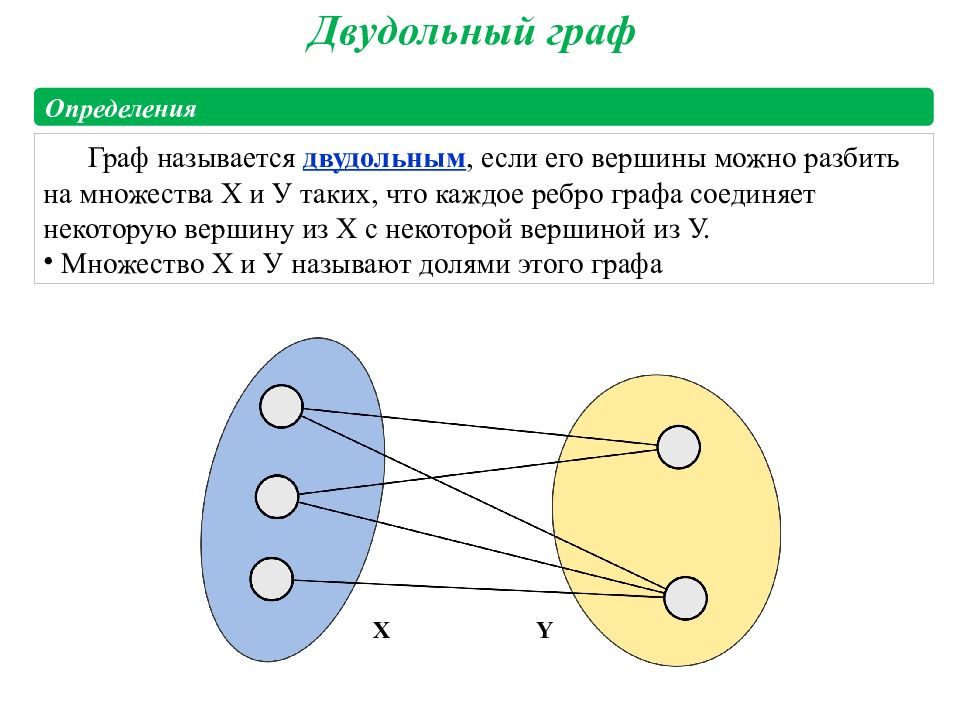

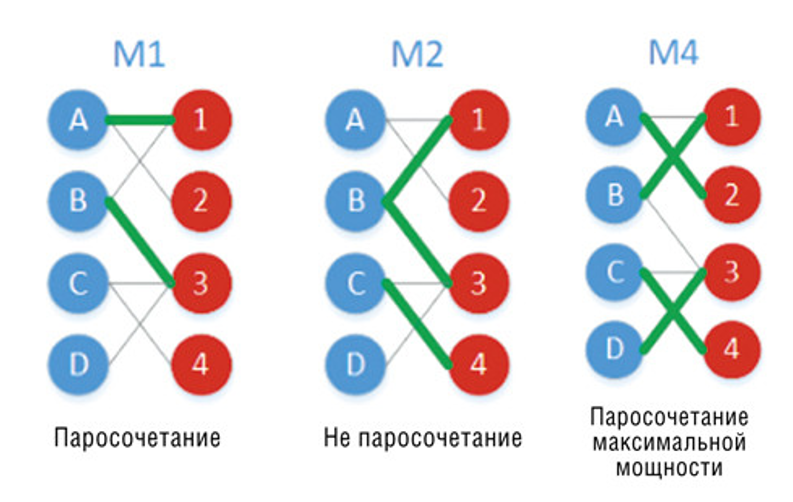

Введём ещё несколько понятий:
**Цепью длины k** назовём некоторый простой путь (т.е. не содержащий повторяющихся вершин или рёбер), содержащий ровно **k** рёбер.

**Чередующейся цепью** относительно некоторого паросочетания назовём простой путь длины **k** в котором рёбра поочередно принадлежат/не принадлежат паросочетанию.

**Увеличивающей цепью** относительно некоторого паросочетания назовём чередующуюся цепь, у которой начальная и конечная вершины не принадлежат паросочетанию.

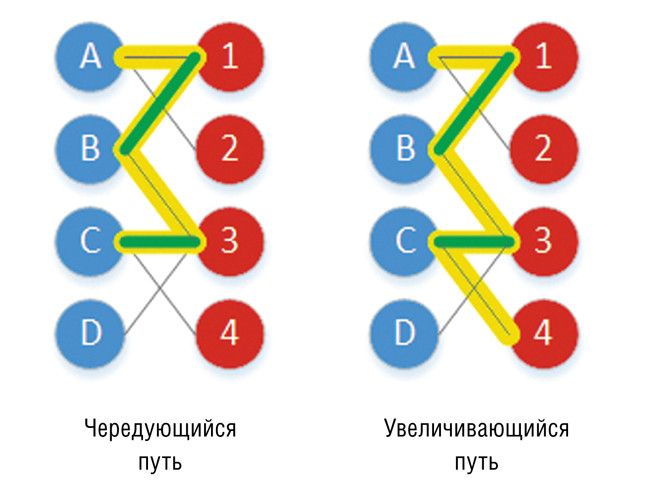

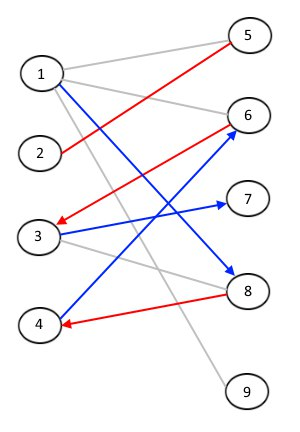

Здесь красными помечены вершины паросочетания, а в графе есть увеличивающая цепь: 1→8→4→6→3→7

Как подсказывает название, с помощью увеличивающей цепи можно увеличить мощность паросочетания на единицу. Для этого можно взять такую цепь и провести чередование: убрать из паросочетания все рёбра, принадлежащие цепи, и вместо них добавить все остальные ребра цепи.

Всего в увеличивающей цепи нечетное число рёбер, а первое и последнее были не в паросочетании. После чередования каждая затронутая вершина будет соединена ровно с одной из другой доли. Значит, после чередования паросочетание осталось корректным, а его мощность увеличилась ровно на единицу.

В примере выше добавятся синие рёбра (1,8), (3,7) и
 (4,6), а удалятся красные (3,6) и (4,8). С ребром
(2,5) ничего не случится — оно не в увеличивающей цепи. Таким образом, размер паросочетания увеличится на единицу.

Раз чередованием увеличивающей цепи можно увеличить мощность паросочетания на единицу, то у максимального паросочетания увеличивающих цепей быть не должно. Оказывается, обратное тоже верно.

## Теорема Бержа
**Теорема.** Паросочетание без увеличивающих цепей является максимальным.

**Доказательство** проведём от противного: пусть есть два паросочетания вершин $∣A∣≤∣B∣$, и для $A$ нет увеличивающих путей. Покажем, как найти этот путь и увеличить $A$ на единицу.

Раскрасим ребра из паросочетания, соответствующего
$A$ в красный цвет, $B$ — в синий, а ребра из обоих паросочетаний — в пурпурный. Рассмотрим теперь граф из только красных и синих ребер. Так как это фактически симметричная разность двух паросочетаний, у каждой вершины будет не более 2 смежных ребер. Значит, любая компонента связности в нём представляет собой либо путь, либо цикл, состоящий из чередующихся красных и синих ребер. В любом цикле будет равное число красных и синих рёбер, а так как всего синих рёбер больше, то должен существовать путь, начинающийся и оканчивающийся синим ребром — он и будет увеличивающей цепью для $A$, а значит
$A$ не максимальное, и мы получили противоречие.


## Алгоритм Куна
**Лемма Бержа** говорит о том, что паросочетание без увеличивающих цепей является максимальным.

Её важное следствие состоит в том, что максимальное паросочетание можно строить инкрементально, на каждом шаге делая поиск увеличивающей цепи и проводя её чередование.

**Алгоритм Куна** ровно в этом и заключается — начнем с пустого паросочетания и будем искать увеличивающие цепи, пока они ищутся.

Для поиска увеличивающей цепи можно мысленно построить граф, в котором из правой доли в левую можно идти только по рёбрам паросочетания, а из левой в правую — по любым. Тогда можно запустить поиск любого пути из свободной вершины левой доли в какую-нибудь свободную вершину правой доли в измененном графе, и ровно такой путь и будет увеличивающим.

In [4]:
def kuhn_matching(graph):
    """Алгоритм Куна для двудольного графа
    graph[u] = список соседей v из правой доли
    """
    n = len(graph)  # левая доля
    pairU = [-1] * n  # пара для U (левая)
    pairV = [-1] * 1000  # пара для V (правая, max размер)

    def dfs(u, visited):
        """Ищет увеличивающую цепь из u"""
        for v in graph[u]:
            if not visited[v]:
                visited[v] = True
                # v свободна ИЛИ можем переставить pairV[v]
                if pairV[v] == -1 or dfs(pairV[v], visited):
                    pairU[u] = v
                    pairV[v] = u
                    return True
        return False

    matching = 0
    for u in range(n):
        if pairU[u] == -1:  # свободная вершина U
            visited = [False] * 1000
            if dfs(u, visited):
                matching += 1

    return matching, pairU

graph = [
    [0,1],  # A → W,X
    [1],    # B → X
    [2]     # C → Y
]

size, pairs = kuhn_matching(graph)
print(f"Размер паросочетания: {size}")
print("Пары L→R:", pairs)


Размер паросочетания: 3
Пары L→R: [0, 1, 2]


Алгоритм ровно $n$ раз ищет увеличивающий путь, каждый раз просматривая не более $m$ рёбер, а значит суммарно отработает за $O(nm)$.

Ещё несколько определений:

Пусть $G = (V, E)$ – граф
* Мн-во $I ⊂ V$ называется независимым, если для любых $a,b ∈ I$ не существует ребра $(a,b) ∈ E$.
* Мн-во $C ⊂ V$ называется вершинным покрытием, если любое $(u,v) ∈ E$ : $u ∈ C$ & $v ∈ C$

**Утверждение**: если $I$ – независимое множество, то $V\I$ – вершинное покрытие

Красные вершины – минимальное вершинное покрытие.


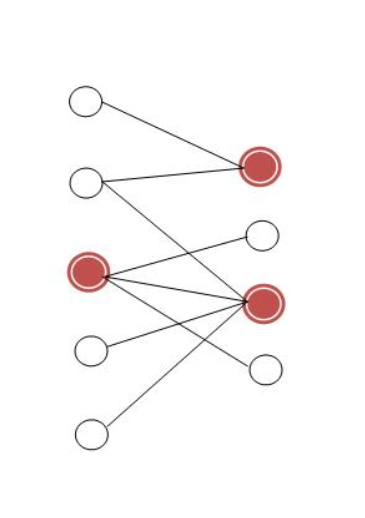

## Теорема Кёнига

**Теорема Кёнига** утверждает: в двудольном графе размер наибольшего паросочетания равен размеру наименьшего вершинного покрытия.
​

Формула: $ν(G) = τ(G)$ где:

$ν(G)$ = размер максимального паросочетания

$τ(G)$ = размер минимального вершинного покрытия

```python
Паросочетание M: рёбра не пересекаются по вершинам
Вершинное покрытие C: каждая ребро инцидентно хотя бы одной вершине C
```
```
1. |M| ≤ |C| очевидно (каждое ребро M → ≥1 вершина C)

2. Кёниг доказывает обратное: |C| ≤ |M|

3. Конструкция минимального C из максимального M:
   - Находим максимальное M алгоритмом Куна
   - Строим направленный граф достижимости
   - C = (L \ свободныеL) ∪ (R ∩ достижимыеR)
```
Пусть M – максимальное паросочетание в G. Построим ориентированный граф D, где ребра из M ориентируем справа налево (из R в L), а ребра не из M – слева направо (из L в R).  Запустим обход в глубину из всех не насыщенных паросочетанием вершин левой доли. Разобьем вершины каждой доли графа на два множества: те, которые были посещены в процессе обхода (L+, R+), и те, которые не были посещены в процессе обхода (L-, R-). Тогда L- ∪ R+ – минимальное вершинное покрытие, а L+ ∪ R- – максимальное независимое множество, а |L- ∪ R+| = |M|.


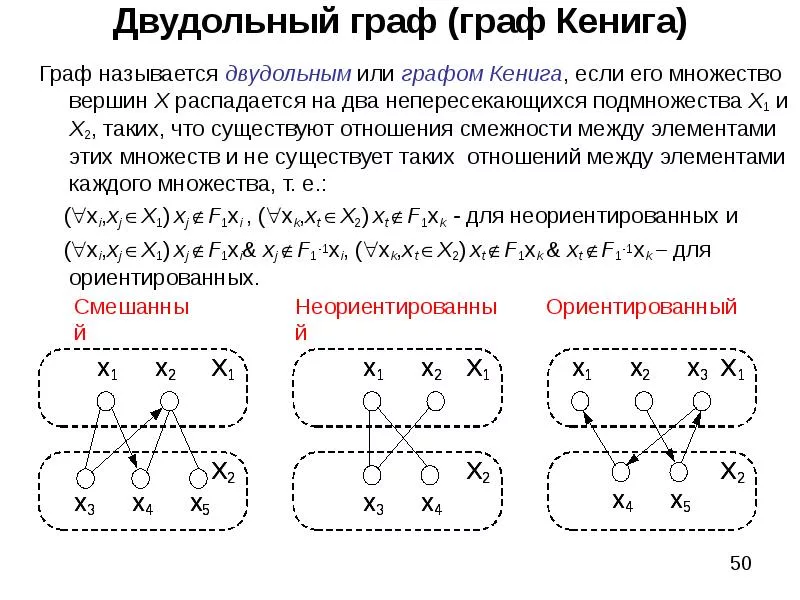

## Лемма Холла (теорема о свадьбах)

Очень удобный критерий в задачах, где нужно проверить, что паросочетание существует, но при этом не требуется строить его явно.


* Совершенное паросочетание  
**Определение**: Паросочетание, покрывающее ВСЕ вершины графа. Каждая вершина инцидентна ровно одному ребру из паросочетания.

* Полное паросочетание  
**Определение**: В двудольных графах — паросочетание, насыщающее всю левую долю (все вершины L имеют пару). Правая доля может быть частично свободной.

**Лемма Холла.** Полное паросочетание существует тогда и только тогда, когда любая группа вершин левой доли соединена с не меньшим количеством вершин правой доли.

**Доказательство**. В одну сторону понятно — если совершенное паросочетание есть, то для любого подмножества вершин левой доли можно взять вершины правой, соединенные с ним паросочетанием.

В другую сложнее — нужно воспользоваться индукцией. Будем доказывать, что если паросочетание не полное, то можно в таком графе найти увеличивающую цепь, и с её помощью увеличить паросочетание на единицу.

*База индукции*: одна вершина из $L$, которая по условию соединена с хотя бы одной вершиной из $R$.

*Индукционный переход*: пусть после $k<n$ шагов построено паросочетание $M$. Докажем, что в $M$ можно добавить вершину $v$ из $L$, не насыщенную паросочетанием.

Рассмотрим множество вершин $H$ — все вершины, достижимые из $x$, если можно ходить из правой доли в левую только по рёбрам паросочетания, а из левой в правую — по любым (мы такой граф по сути строим, когда ищем увеличивающую цепь в алгоритме Куна)

Тогда в $H$ найдется вершина $y$ из $R$, не насыщенная паросочетанием. Иначе, если такой вершины нет, то получается, что если рассмотреть вершины $H_L$ (вершины левой доли, насыщенные паросочетанием), то для них не будет выполнено условие, что $∣H_L∣≤∣N(H_L)∣$ (здесь $N(X)$ — множество вершин, соединенным паросочетанием с $X$).

Тогда должен существовать путь из $x$ в $y$, и он будет увеличивающим для паросочетания $M$, потому что из $R$ в $L$ мы всегда шли только по ребрам паросочетания. Проведя чередование вдоль этого пути, получим большее паросочетание, следовательно предположение индукции верно.

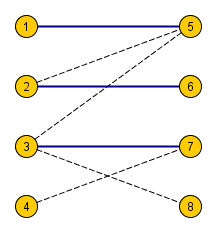

Итак, В двудольном графе с долями $L$ и $R$ существует полное паросочетание (все вершины $L$ можно сопоставить с $R$) тогда и только тогда, когда:
```
∀ S ⊆ L: |N(S)| ≥ |S|
Где:

N(S) = множество всех соседей вершин из S в R
|N(S)| = количество различных соседей
```
Простыми словами
```
"Любая группа из k парней
знакома хотя бы с k девушками"
```

Обсудим: https://ru.algorithmica.org/cs/matching/matching-problems/